# EDA For The DataSet

## Objectives

- Transform the InvoiceDate column to pandas datetime
- Perform statistical tests to check for hypothesis compatibility
- Look for correlations between the columns in the dataset
- Look for outliers and variance from hypothesis Zero for hypothesis with unique columns
- Use plots where possible to visualise the data and check for hypothesis compatibility
- Use Parametric and Non Parametric tests to test possible correlations between columns


## Inputs

CSV file used:

Sales_InvoiceData_Visualization.csv


## Outputs

Plots for testing validity of each hypothesis before considering visualisation


## Additional Comments

Developed an experimental ETL library which is in this project (modETL_library.py) 
Has lots of cool features so will be interesting to see how it works "in the field"



In [132]:
#import libraries
import os
import numpy as np
import pandas as pd
import plotly.express as px
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats
from scipy.stats import kruskal
#added by me for visualisation fine tuning
from matplotlib.ticker import MultipleLocator
from scipy.stats import f_oneway
from scipy.stats import pearsonr
from scipy.stats import spearmanr

#added by me for plotly.express visualisation issue
import nbformat 

#below solution provided by chatGPT 
import sys
from pathlib import Path

project_root = Path.cwd().parent

if str(project_root / "assets" / "python_files") not in sys.path:
    sys.path.insert(0, str(project_root / "assets" / "python_files"))
    
import modGlobal
import modETL_Library as modETL
#end solution provided by chatGPT

# Section 1 - Initalisation

## Intitialise All Variables To Be Used In Global Stack 


In [ ]:
#DataFrame variables for EDA
dfSales_DataSet_Work = None
dfSales_DataSet_Temp = None
dfSales_DataSet_Temp1 = None
dfSales_DataSet_Temp2 = None
dfSales_DataSet_Sample1 = None
dfSales_DataSet_Sample2 = None

#stores current directory
strCurrentDir = ""

#other vars
dictDataFrames = dict()
fig = None
axis = None
fltShapiroStat = 0.0
fltShapiroP = 0.0
fltMannWhitneyU = 0.0
fltMannWhitneyUStat = 0.0
fltMannWhitneyUp = 0.0
fltTStatistic = 0.0 
fltPValue = 0.0
fltStat = 0.0
fltRHO = 0.0
fltR = 0.0
intStart = 0
intEnd = 0
intYear = 0
objGroups = None



## Set Current Directory To Base Project Directory


In [134]:
#get project directory - default is jupyter notebook sub folder as that is where this file is located!
#so move back one to the project root path
# Source - https://stackoverflow.com/a/17726833
# Posted by chimpsarehungry
# Retrieved 2026-07-05, License - CC BY-SA 3.0

#get current folder
strCurrentDir = os.getcwd()

#is the last part of the path the project directory?
if not strCurrentDir.endswith(modGlobal.CNST_STR_PROJECT_DIR):
   #get current working directory and move back one to the project root path
   strCurrentDir =  os.path.normpath(os.getcwd() + os.sep + os.pardir)
   os.chdir(os.path.dirname(strCurrentDir))
   #change directory
   os.chdir(strCurrentDir)

#confirm current directory is project directory
print(f"Current Directory: \n {os.getcwd()}")

Current Directory: 
 /Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis


# Section 2

- Read csv file
- Convert Date column to datetime
- Look at skew, kurtosis and Q-Q plots for ALL numeric columns

Why all numeric columns?

Just being thorough and want to see if there are any other columns that may be useful for analysis



In [135]:
#read file from working files folder
#ETL library returns a dictionary of all files in the folder with the attribute name
#set to the actual csv filename
dictDataFrames = modETL.funcReadVisualisationFilesReturnDictionary()
          
dfSales_DataSet_Work = dictDataFrames["Sales_InvoiceData_Visualisation.csv"]
                                  

1 csv Files Read Into DataFrames

DataFrames Created:
Sales_InvoiceData_Visualisation.csv




/Users/rogerwilliams/Projects/Python/CourseProjects/Project3-SalesAnalysis/assets/python_files/modETL_Library.py:452: DtypeWarning: Columns (0: InvoiceID) have mixed types. Specify dtype option on import or set low_memory=False.
  dfTemp = pd.read_csv(os.getcwd() + modGlobal.CNST_STR_DATA_VISUALISATIONPATH + "/" + strFile)


# Transform The Date Column To Pandas Datetime

In [136]:
#convert Date column to pandas datetime
dfSales_DataSet_Work["InvoiceDate"] = pd.to_datetime(dfSales_DataSet_Work["InvoiceDate"], format="%d/%m/%Y") 

# Get Column Skew/Kurtosis

DataFrame Skew Values Per Column:
Unnamed: 0           Skew: 0.00 - Approximately Symmetrical Kurtosis: -1.20
InvoiceDate          Skew: 0.16 - Approximately Symmetrical Kurtosis: -1.20
InvoiceQty           Skew: 27.17 - Highly Positively Skewed Kurtosis: 1252.70
InvoiceAmt           Skew: 24.63 - Highly Positively Skewed Kurtosis: 1040.43
Day                  Skew: -0.03 - Highly Negatively Skewed Kurtosis: -1.16
Month                Skew: -0.01 - Highly Negatively Skewed Kurtosis: -1.17
Year                 Skew: 0.14 - Approximately Symmetrical Kurtosis: -1.24
Quarter              Skew: 0.00 - Approximately Symmetrical Kurtosis: -1.32

Q-Q Plot For Column: Unnamed: 0


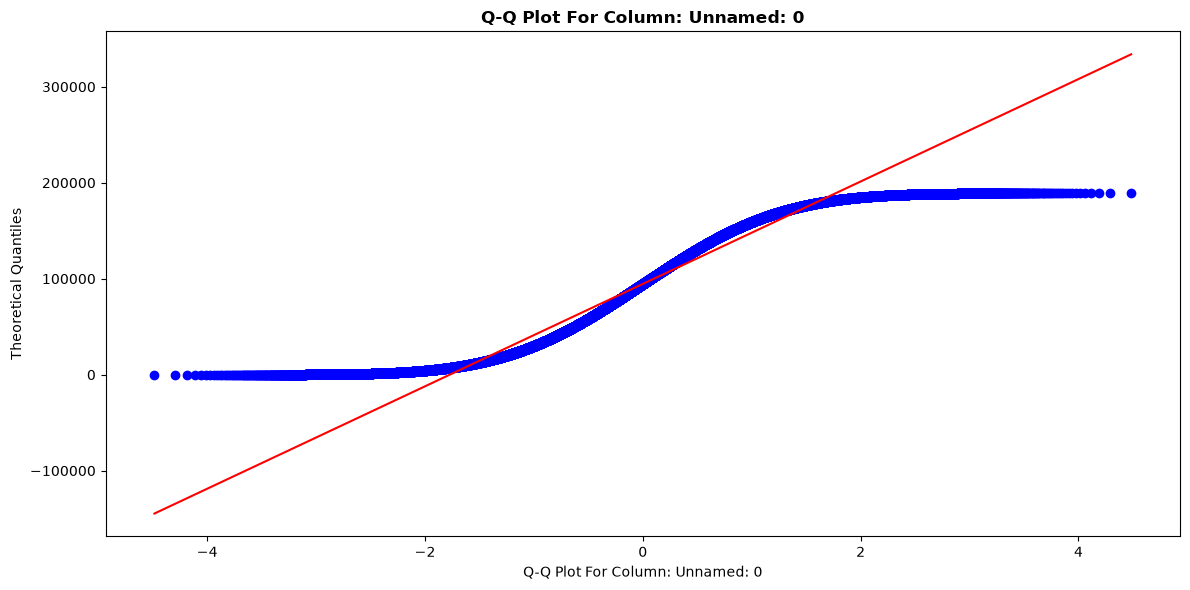



Q-Q Plot For Column: InvoiceDate


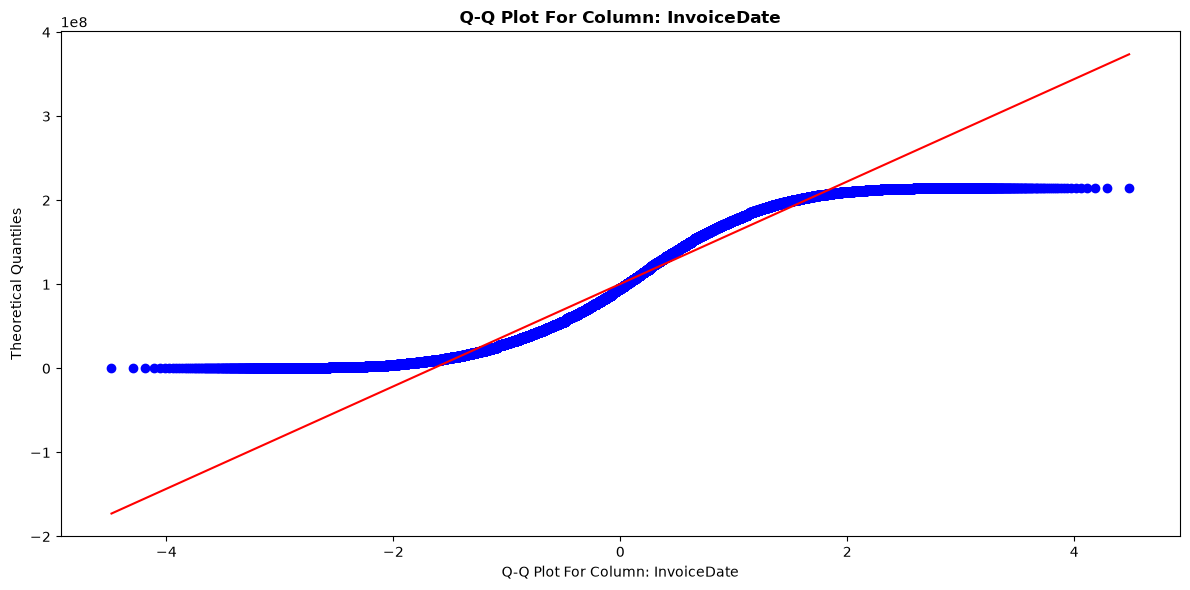



Q-Q Plot For Column: InvoiceQty


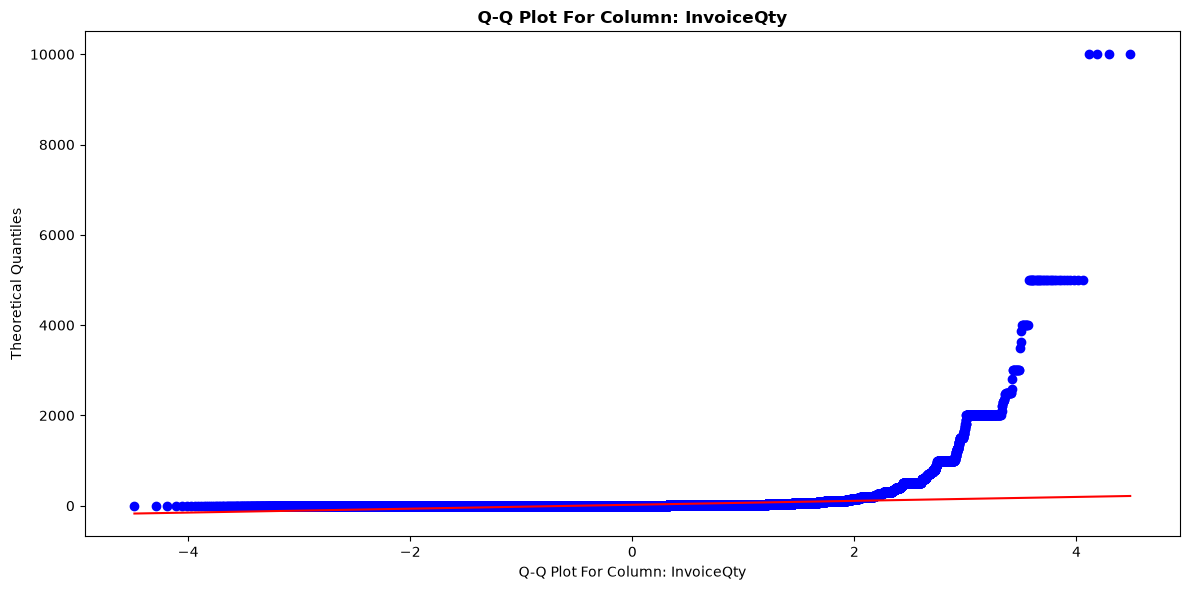



Q-Q Plot For Column: InvoiceAmt


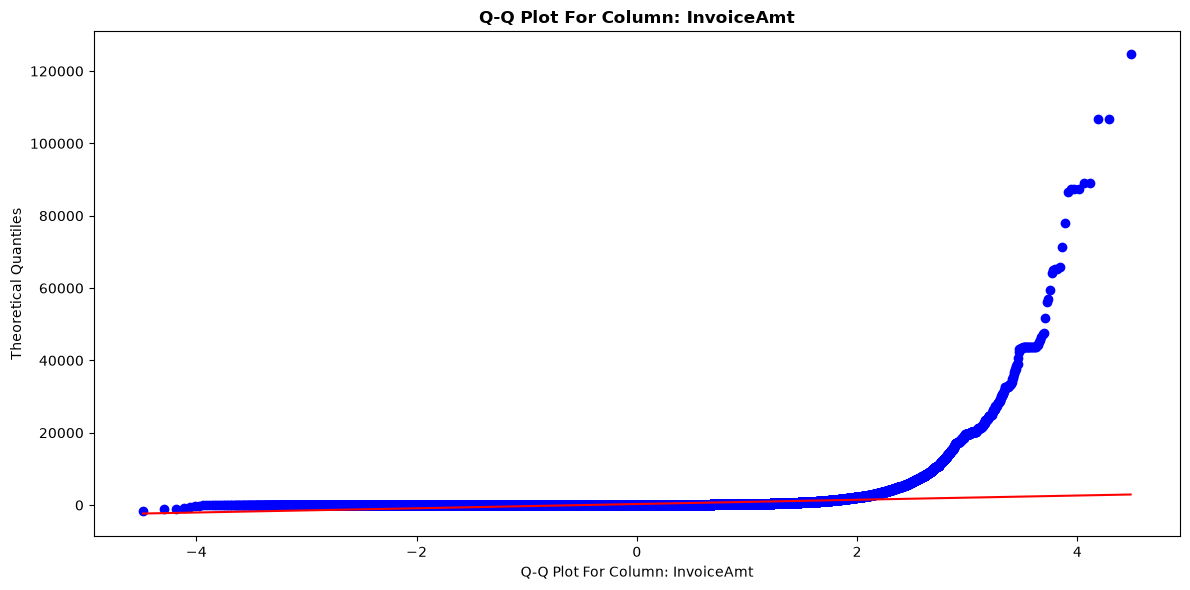



Q-Q Plot For Column: Day


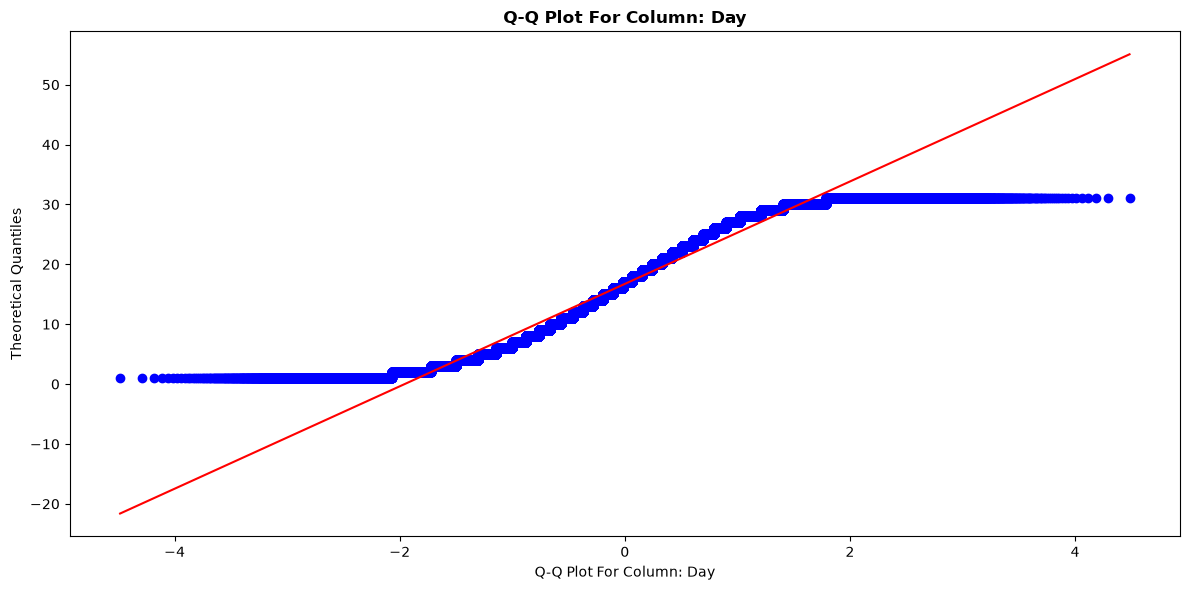



Q-Q Plot For Column: Month


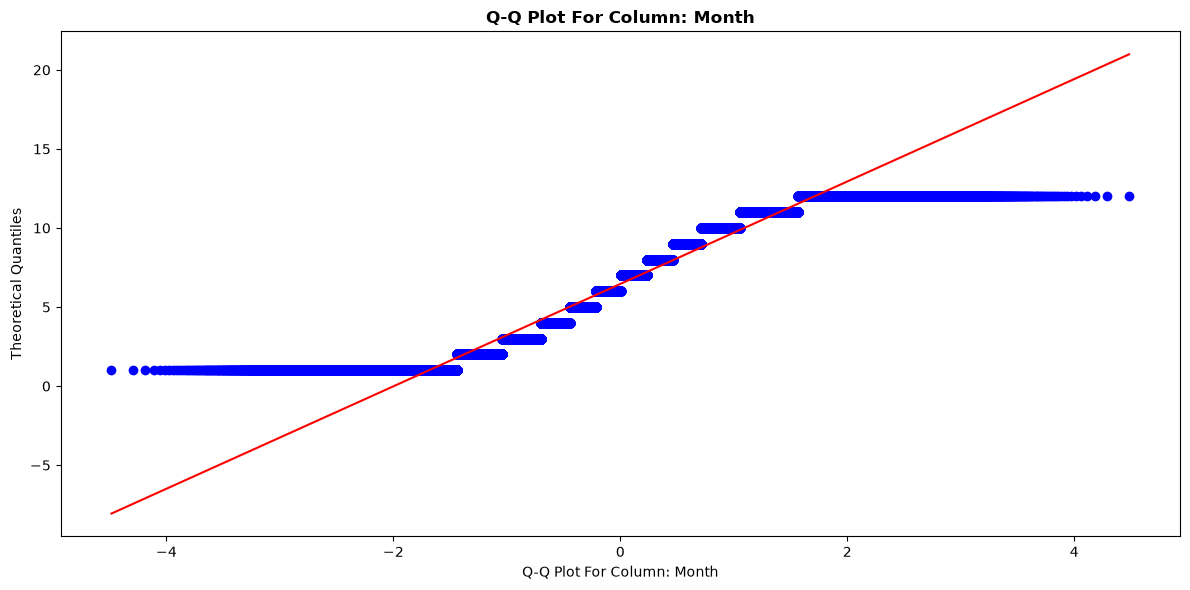



Q-Q Plot For Column: Year


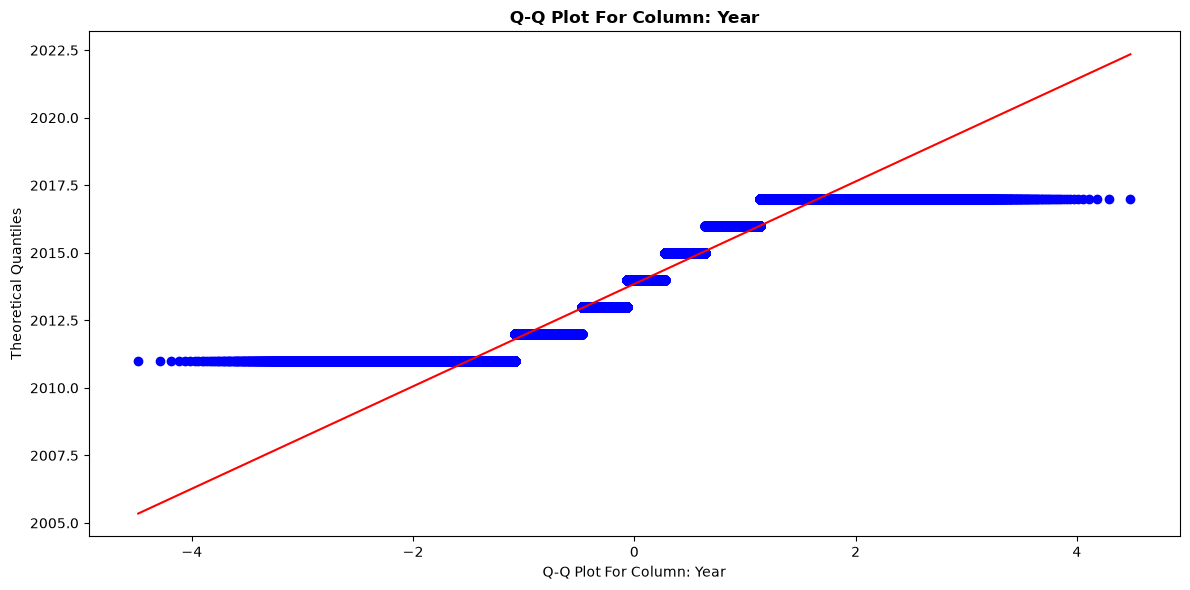



Q-Q Plot For Column: Quarter


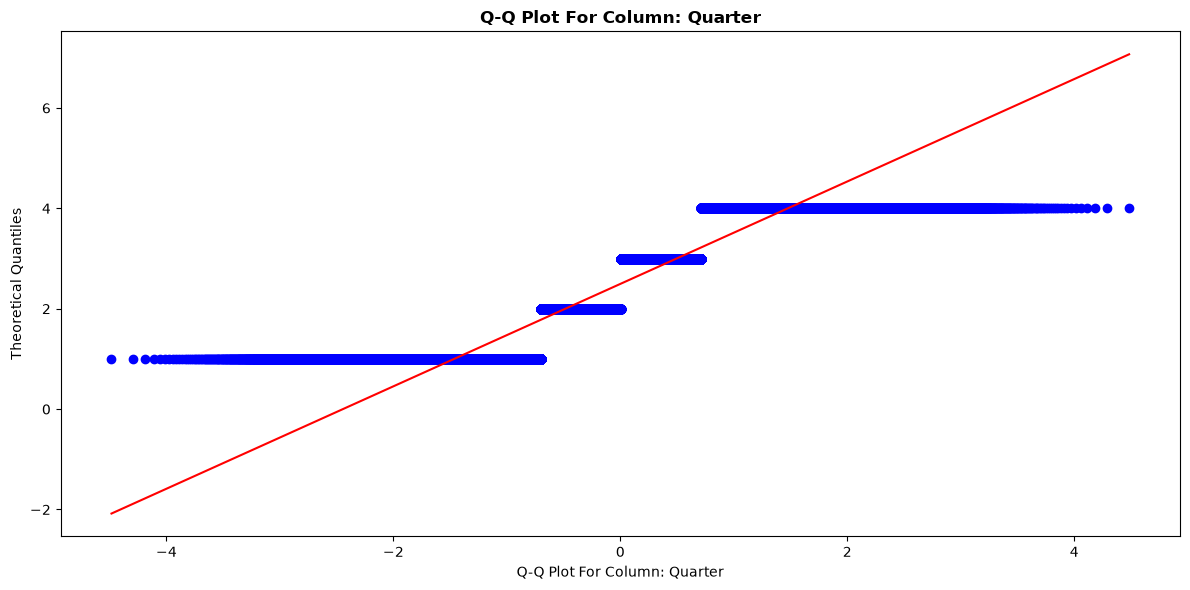

In [137]:
#get column skew/kurtosis and show some Q-Q plots where possible

modETL.funcGetColumnSkew(dfSales_DataSet_Work)

# Observations: EDA - Sales DataSet

Due to the nature of the columns not much value can be gained from skew and kurtosis. It is obvious it is in correlations where real meaning can be obtained

The bar chart shows Invoice qty/amount columns as being most skewed which is not surprsing so typically need to correlated in order for the values to have meaning


# Section 3 - More Analysis

Here we perform these tests where possible:

- Missing values heatmap
- Q-Q Plots
- Shapiro-Wilk Test
- Parametric Tests
- Non-Parametric Tests




# Missing Values Heatmap

Double check what we did in the ETL notebook and use a heatmap to show any missing values
Am expecting just the CUS_ContactName column to appear in the plot with values, luckily thiis column
is not required for visualisation so will ignore it

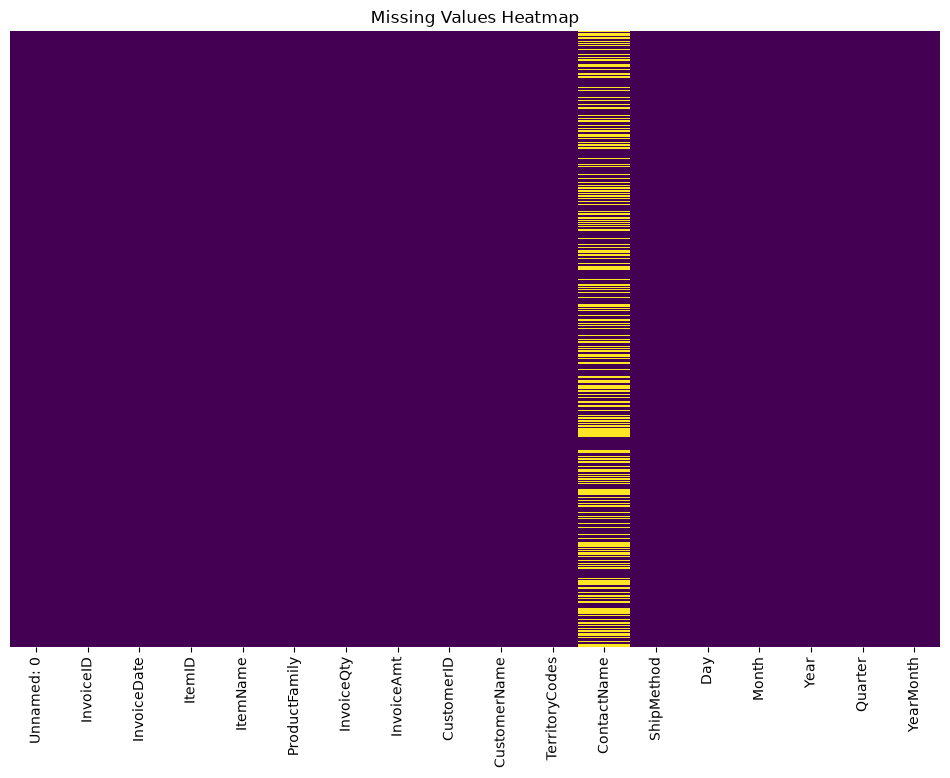

In [138]:
#create missing values heatmap
plt.figure(figsize=(12, 8))

sns.heatmap(
    dfSales_DataSet_Work .isna(),
    cbar=False,
    yticklabels=False,
    cmap="viridis"
)

plt.title("Missing Values Heatmap")
plt.show()



## Observations - Missing Values Heatmap

As expected the only column with missing values is CUS_ContactName which is not required for visualisation so will ignore it!

## How Many? - Values

See how many values in key columns

In [139]:
#get how many? values for useful columns

print("How Many? - Values")
print("=" * len("How Many? - Values"))
print(f"Rows: {len(dfSales_DataSet_Work)}")
print(f"Invoices: {dfSales_DataSet_Work['InvoiceID'].nunique()}")
print(f"Customers: {dfSales_DataSet_Work['CustomerID'].nunique()}")
print(f"Items: {dfSales_DataSet_Work['ItemID'].nunique()}")
print(f"Product Families: {dfSales_DataSet_Work['ProductFamily'].nunique()}")
print(f"Territories: {dfSales_DataSet_Work['TerritoryCodes'].nunique()}")
print(f"Ship Methods: {dfSales_DataSet_Work['ShipMethod'].nunique()}")
print()

How Many? - Values
Rows: 189151
Invoices: 78012
Customers: 1928
Items: 7558
Product Families: 130
Territories: 34
Ship Methods: 12



## Observations:How Many? - Values

Not seeing any wayward values, nice consistency in the dataset, which is good for visualisation and analysis

## How Many? - Numeric Values

Now check:

- InvoiceAmt <- looking for mean/median/sum and negative amounts (credits)
- InvoiceQty

In [140]:
#get how many? values for useful columns

print("How Many? - Values")
print("=" * len("How Many? - Values"))
print(f"Rows: {len(dfSales_DataSet_Work)}")
print(f"Invoice Amount Sum: {dfSales_DataSet_Work['InvoiceAmt'].sum()}")
print(f"Invoice Amount Mean: {dfSales_DataSet_Work['InvoiceAmt'].mean()}")
print(f"Invoice Amount Median: {dfSales_DataSet_Work['InvoiceAmt'].median()}")
print(f"Invoice Amount Negative: {(dfSales_DataSet_Work['InvoiceAmt'] < 0).sum()}")
print(f"Invoice Qty Sum: {dfSales_DataSet_Work['InvoiceQty'].nunique()}")
print()

#show negative invoiceamt records
dfSales_DataSet_Work[dfSales_DataSet_Work["InvoiceAmt"] < 0].sort_values("InvoiceAmt").head(20)


How Many? - Values
Rows: 189151
Invoice Amount Sum: 56154043.3
Invoice Amount Mean: 296.8741550401531
Invoice Amount Median: 47.32
Invoice Amount Negative: 10
Invoice Qty Sum: 592



,Unnamed: 0,InvoiceID,InvoiceDate,ItemID,ItemName,ProductFamily,InvoiceQty,InvoiceAmt,CustomerID,CustomerName,TerritoryCodes,ContactName,ShipMethod,Day,Month,Year,Quarter,YearMonth
103780,103780,CM233343,2014-07-10,FP-MISC,Miscellaneous,Commissioning,1.0,-1723.44,S1792,Grant & Stone Limited,South East/London,NaN,UK Carrier,10,7,2014,3,31/07/2014
8621,8621,CM185641,2011-06-10,KAL214/M3/A/SG ORB,Kalix 2x14W T5 M3 Style A. Silver Grey,Kalix,1.0,-1100.88,IR13,Wesco Electrical Limited,South East/London,NaN,Export,10,6,2011,2,30/06/2011
131705,131705,CM246356,2015-08-24,AR2X8/110D ORB,110V AC/DC 2x8W Arc Clear Diffuser,Arc,1.0,-947.71,1028,Imci Services Ltd,South East/London,do not change above email,Export,24,8,2015,3,31/08/2015
161070,161070,CM259611,2016-10-25,FP-MISC,Miscellaneous,Fire Product,1.0,-808.34,526,Cesar Debbas & Fils,South East/London,Fadia Sakr,Export,25,10,2016,4,31/10/2016
129765,129765,CM245429,2015-07-27,PIC8/NM3/E ORB,8W NM3 S/Sided Pico E/Box White Economy Version,Pico,1.0,-526.93,1607,Zubair Electric LLC,South East/London,MR GURURAJ HEGDE,Export,27,7,2015,3,31/07/2015
133716,133716,CM247313,2015-09-24,DY/LED/M3/CR/3K ORB,"Dyode LED M3 Ceiling Mounted D/lighter, Corrid...",Dyode,1.0,-353.52,30,D C,South East/London,Sandi Jenkinson,Despatch Next Day,24,9,2015,3,30/09/2015
11607,11607,CM187234,2011-07-12,PLR5418P3 ORB,M3 LowProfile Module+DDP 4x4Ah For Use With 18...,PLR-Range,1.0,-195.30,1079,EUROLIGHTING LTD T-A E2 CONTRACT LIGHTING,South East/London,Mark Adams/Jan Scrivens,UK Carrier,12,7,2011,3,31/07/2011
132605,132605,CM246743,2015-09-08,LAR/LED/CH/4K ORB,Larino Mains LED Chrome finish Inc 4000K LEDs ...,Larino,1.0,-66.11,534,GLAMOX LUXONIC LIMITED,South East/London,NaN,Export,8,9,2015,3,30/09/2015
163352,163352,CM260609,2016-11-29,FP-MISC,Miscellaneous,Lumino,1.0,-53.34,589,J Smith,South East/London,NaN,UK Carrier,29,11,2016,4,30/11/2016
132680,132680,CM246797,2015-09-09,na/led/m3 orb,Napoli 6500K LED M3 S/Sided E/Sign,Napoli,1.0,-36.76,255,4D Lighting Limited,South East/London,NaN,UK Carrier,9,9,2015,3,30/09/2015


## Observations: How Many? - Numeric Values

There are only 10 negative values in the InvoiceAmt column which is good for the customer!


## Distribution Of Invoice Amounts

Show a plot of the distribution of invoice amounts

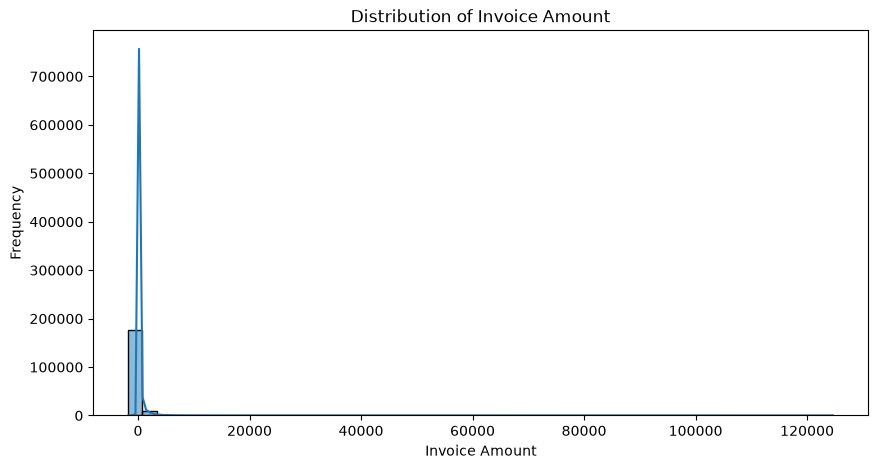

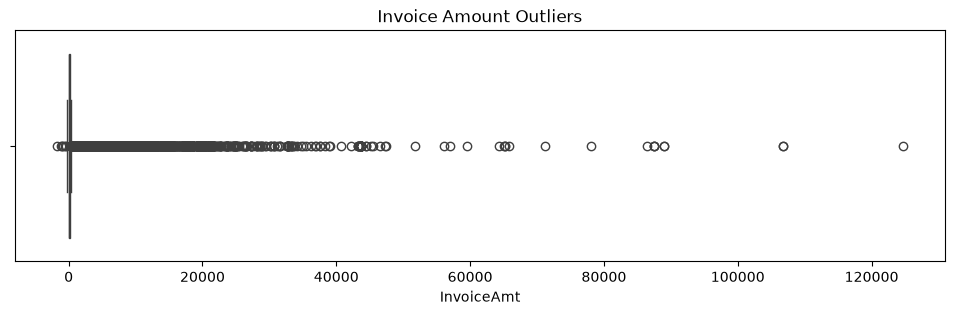

In [141]:
#show distribution of invoice amounts
plt.figure(figsize=(10, 5))

sns.histplot(
    dfSales_DataSet_Work["InvoiceAmt"],
    bins=50,
    kde=True
)

plt.title("Distribution of Invoice Amount")
plt.xlabel("Invoice Amount")
plt.ylabel("Frequency") 
plt.show()


#lets chuck it into a bpoxplot to re-inforce the visualisation
plt.figure(figsize=(12, 3))

sns.boxplot(x=dfSales_DataSet_Work["InvoiceAmt"])

plt.title("Invoice Amount Outliers")
plt.show()



## Observations: Distribution Of Invoice Amounts

Small amount of outliers, which is good as means data is not inherently skewed or even worse corrupt!
Nice to see the vast majority of the data is clustered in to 0 to 38000 range, which shows a certain
consistency in the dataset



## Check For Negative InvoiceQtys

Make sure the customer did not magically manage to sell products with a quantity less than one
That would get accounts attention! 

In [142]:
dfSales_DataSet_Work[dfSales_DataSet_Work["InvoiceQty"] <= 0]


,Unnamed: 0,InvoiceID,InvoiceDate,ItemID,ItemName,ProductFamily,InvoiceQty,InvoiceAmt,CustomerID,CustomerName,TerritoryCodes,ContactName,ShipMethod,Day,Month,Year,Quarter,YearMonth


## Observations: Check For Negative InvoiceQtys

Thankfully no values less than zero, if there were would have to consider whether to move those records out of the
live dataset into a new one for preservation and delete from the "live" datatset, or leave in......

Personally would move them out of the data and show the data to the customer and ask under what business conditions
this could occur

## Is There A Significant Difference In InvoiceAmt Between TerritoryCodes?

Hypothetical test, to check data has no anomalies in it, should be a correlation!

In [143]:
#show a plot comparing territorycodes and their invoice amounts
dfSales_DataSet_Temp = dfSales_DataSet_Work.copy()

#filter by last year of data
dfSales_DataSet_Temp = dfSales_DataSet_Temp[dfSales_DataSet_Temp["Year"] == dfSales_DataSet_Temp["Year"].max()]

#use a bar plot as it looks cleaner
fig = px.bar(
    dfSales_DataSet_Temp,
    x="TerritoryCodes",
    y="InvoiceAmt",
    barmode="group",
    title=f"Invoice Amount By Territory For {intYear}",
    labels={"InvoiceAmt": "Invoice Amount", "TerritoryCodes": "Territory Codes"}
)

fig.update_layout(
    xaxis_title="Territory Codes",
    yaxis_title="Invoice Amount",
    legend_title="Product Family",
    font=dict(size=12),
    title_font=dict(size=16),
    title_x=0.5,
    title_y=0.9,
    margin=dict(l=50, r=50, t=120, b=50),
    height=900,
    width=1000
)

fig.show()




## Observations: Is There A Significant Difference In InvoiceAmt Between TerritoryCodes?

Yes! Nice to see the data is consistent and has a decent spread, pity I could not "zoom" in to show all them
small values

# Parametric/Non Parametric Tests

Run tests on these column combinations:
- TerritoryCode and InvoiceAmt
- InvoiceQty and InvoiceAmt
- ItemID and InvoiceAmt

# TerritoryCodes and InvoiceAmt

In [144]:
#run Kruskal-Wallis test to see if there is a significant difference between the means of the groups
objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("TerritoryCodes")
]

fltStat, fltPValue = kruskal(*objGroups)

print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")


Statistic: 2650.713
p-value: 0.00000


## Observations: Kurskal-Wallis Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

## ANOVA Test

In [145]:
#run ANOVA test to see if there is a significant difference between the means of the groups

objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("TerritoryCodes")
]

fltStat, fltPValue = f_oneway(*objGroups)

print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")


Statistic: 292.132
p-value: 0.00000


## Observations: ANOVA Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

## InvoiceQty and InvoiceAmt

Run Parametric/Non Parametric tests to see if there is a significant deviation from alpha

In [ ]:
#run Pearson correlation

dfSales_DataSet_Temp = dfSales_DataSet_Work[
    ["InvoiceQty", "InvoiceAmt"]
].dropna()

fltR, fltPValue = pearsonr(
    dfSales_DataSet_Temp["InvoiceQty"],
    dfSales_DataSet_Temp["InvoiceAmt"]
)

print(f"r Value = {fltR:.3f}")
print(f"p-value = {fltPValue:.5f}")


Statistic: 11.617
p-value: 0.00000


## Observations: Pearson Correlation Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine


In [147]:
#run Spearman correlation

fltRHO, fltPValue = spearmanr(
    dfSales_DataSet_Work["InvoiceQty"],
    dfSales_DataSet_Work["InvoiceAmt"]
)

print(f"rho = {fltRHO:.3f}")
print(f"p = {fltPValue:.5f}")


rho = 0.453
p = 0.00000


## Observations: Spearman Correlation Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

# ItemID and InvoiceAmt

In [150]:
#run ANOVA test to see if there is a significant difference between the means of the groups

objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("ItemID")
]

fltStat, fltPValue = f_oneway(*objGroups)

print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")

Statistic: 11.617
p-value: 0.00000


## Observations: ANOVA Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

In [151]:
#run Kruskal-Wallis test to see if there is a significant difference between the means of the groups
objGroups = [
    #delete null values
    group["InvoiceAmt"].dropna()
    for _, group in dfSales_DataSet_Work.groupby("ItemID")
]

fltStat, fltPValue = kruskal(*objGroups)

print(f"Statistic: {fltStat:.3f}")
print(f"p-value: {fltPValue:.5f}")

Statistic: 125713.686
p-value: 0.00000


## Observations: Kruskal-Wallis Test

The test yielded a p-value of 0.000, which is less than the alpha (0.05). This indicates that there is a statistically significant difference, which is what I expected, if the p-value was greater than 0.05 then we would have to consider whether the data was genuine

# Observations: EDA - Sales Combined DataSet - Hypothesis 1 - Temperature Column

The probplot central curve in the data shows a skew away from central tendancy and the initial burst of data is a flatline  
The boxplot shows a large number of values below the median a definite skew   
The strip plot shows a  definite deviation from hypothesis Zero  
These plots confirm hypothesis 1 is viable  
The Shapiro-Wilk Test shows 0! This tells us the data is far from normally distributed so again hypothesis Zero is not met  
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0657 which is greater than the alpha (0.05) based on the  
fact all the other test have disproved hypothesis Zero am happy to ignore   
The Parametric test returns p-values of 0.0461 and 0.0230 which is less than alpha (0.05) which disproves hypothesis Zero

**Note:**  
Based on the fact that Parametric and Non Parametric test are designed to use with TWO different datasets e.g. one with store    
type as A and the other as store type B, and with this hypothesis there is no scenario to use that as Temperature and  
Weekly_Sales and continuous values these tests are merely done for consistency of action


# Weekly_Sales Column Tests

- Test the column on its own
- Don't need to test the column in comparision with the Weekly_Sales column as per the hypothesis as this was done previously  
  in the Temperature column tests

In [ ]:
#show Q-Q plot for Weekly_Sales column
    
#filter data for one year
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012]
    
#configure plot
fig, axis = plt.subplots(figsize=(6, 6))

#print Q-Q plot for weekly sales
print("Q-Q Plot For Weekly_Sales For 2012")
print("=" * len("Q-Q Plot For Weekly_Sales For 2012"))
stats.probplot(dfSales_DataSet_Work["Weekly_Sales"], dist="norm", plot=plt)
plt.title("Q-Q Plot For Weekly_Sales", fontweight="bold")
axis.set_xlabel(f"Q-Q Plot For Weekly_Sales")
axis.set_ylabel("Theoretical Quantiles")
plt.tight_layout()
plt.show()

# #now repeat using boxplot
print("BoxPlot For Weekly_Sales For 2012")
print("=" * len("BoxPlot For Weekly_Sales For 2012"))
plt.figure(figsize=(8, 4))
sns.boxplot(x=dfSales_DataSet_Work["Weekly_Sales"])
plt.title("Boxplot For Weekly_Sales For 2012", fontweight="bold")
plt.xlabel("Weekly Sales")
plt.tight_layout()
plt.show()


print()
#Shapiro-Wilk Test for Weekly_Sales column using 3000 sample size due to data size
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work["Weekly_Sales"].sample(3000, random_state=42)
fltShapiroStat, fltShapiroP = stats.shapiro(dfSales_Combined_DataSet_Temp)
print(f"Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: {fltShapiroP:.4f}")



# Parametric/Non Parametric Tests - Hypothesis 1 - Weekly_Sales Column

Will run on Weekly_Sales column to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  
Probably a pointless venture but for consistency will do it anyway!

In [ ]:
#Non Parametric test for Temperature column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()
#get two samples for two years
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Date"].dt.year == 2010]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Date"].dt.year == 2011]["Weekly_Sales"]
#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2)
print("Non Parametric Test Results For Weekly_Sales column For 2010 and 2011")
print("*" * len("Non Parametric Test Results For Weekly_Sales column For 2010 and 2011"))
print(f"Mann-Whitney U Test Results: Stat={fltMannWhitneyUStat}, P={fltMannWhitneyUp:.4f}")
print()

#Parametric Individual T-Test for Weekly_Sales column for 2010 and 2011 set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales column For 2010 and 2011")
print("=" * len("Independent Parametric Test Results For Weekly_Sales column For 2010 and 2011"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
#set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#print mean sales
print(f"Weekly Sales For Sample 1 Mean Sales (2010): £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Weekly Sales For Sample 2 Mean Sales (2011): £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")


Non Parametric Test Results For Weekly_Sales column For 2010 and 2011
*********************************************************************
Mann-Whitney U Test Results: Stat=10971046497.0, P=0.0000

Independent Parametric Test Results For Weekly_Sales column For 2010 and 2011
t-statistic: 3.7295
p-value: 0.0002

Independent Parametric Test Results For Weekly_Sales Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample
t-statistic: 3.7295
p-value: 0.0001
Weekly Sales For Sample 1 Mean Sales (2010): £16,659.04
Weekly Sales For Sample 2 Mean Sales (2011): £15,065.60


# Correlation

In [ ]:
#see correlation betweenWeekly_Sales and Temperature

print(dfSales_DataSet_Work[['Temperature', 'Weekly_Sales']].corr())

              Temperature  Weekly_Sales
Temperature      1.000000     -0.002312
Weekly_Sales    -0.002312      1.000000


# Observations: EDA - Sales Combined DataSet - Hypothesis 1 - Weekly_Sales Column

The probplot central curve in the data shows a massive skew away from central tendancy and the initial burst of data is  
relatively stable  
The boxplot shows a large number of outliers and a definite skew which correlates with the Q-Q plot 
These basic plots confirm hypothesis 1 is viable  
The Shapiro-Wilk Test shows 0! This tells us the data is far from normally distributed so again hypothesis Zero is not met  
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0000 which is lower than the alpha (0.05) disproving    
hypothesis Zero    
The Parametric tests return p-values of 0.0002 and 0.00001 which is less than alpha (0.05) which disproves hypothesis Zero  
The correlation results of Temperature: 1.0000 and Weekly_Sales: -0.002312 we interpret thus:

| Correlation      | Meaning                        |
| ---------------- | ------------------------------ |
| **+1**           | Perfect positive relationship  |
| **+0.7 to +1**   | Strong positive relationship   |
| **+0.3 to +0.7** | Moderate positive relationship |
| **0 to +0.3**    | Weak positive relationship     |
| **0**            | No linear relationship         |
| **-0.3 to 0**    | Weak negative relationship     |
| **-0.7 to -0.3** | Moderate negative relationship |
| **-1 to -0.7**   | Strong negative relationship   |
| **-1**           | Perfect negative relationship  |

So we can see from the results a change in temperature has ab effect on Weekly_Sales how much over time is best left for  
visualisation as this just shows there *is* an effect

**Note:**  
Based on the fact that Parametric and Non Parametric tests are designed to work with TWO different dataset variations e.g. one  
with store type as A and the other as store type B, and with this hypothesis there is no scenario to use that as Temperature  
and Weekly_Sales are continuous values thus these tests are merely done for consistency of action

# Final Observations: EDA - Sales Combined DataSet - Hypothesis 1

Based on the Q-Q plots it is clear that hypothesis Zero is *not* met also the strip plot comparing Weekly_Sales against  
Temperature shows a definite skew away from central tendancy which is further proof hypothesis Zero is *not* met
The Parametric test where void as the hypothesis did not meet the criteria they are designed for but again for consistency  
of action they where done anyway 

# Hypothesis 2

Sales differences between holiday and non-holiday weeks per store in the last 12 months

# Tests

- Because IsHoliday is boolean nothing of any value (pun intended) can be gleaned from running any tests on its values  
  so will skip them
- No need to run Q-Q plots as already done in previous tests for Temperature column  
- Because Weekly_Sales is a continuous value we can run the Parametric tests! 
- Show violin plot for distribution for all rows then for one year

# Parametric/Non Parametric Tests - Hypothesis 2

Will run on Weekly_Sales column comparing when IsHoliday is true/false to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  


In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()

#get two samples for two years
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == True]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == False]["Weekly_Sales"]
#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False")
print("*" * len("Non Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False"))
print(f"Mann-Whitney U Test Results: Stat={fltMannWhitneyUStat}, P={fltMannWhitneyUp:.4f}")
print()

#Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
#set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where IsHoliday Is True And False"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Holiday Weeks Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Non-Holiday Weeks Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

#show violin plot for distribution
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_DataSet_Work, x="IsHoliday", y="Weekly_Sales")
plt.title("Weekly Sales Where Holiday Is True/False All Rows", fontweight="bold")
plt.xlabel("IsHoliday")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","IsHoliday"]]

#show violin plot for distribution
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="IsHoliday", y="Weekly_Sales")
plt.title("Weekly Sales Where Holiday Is True/False For 2010", fontweight="bold")
plt.xlabel("IsHoliday")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
          

# Correlation

In [ ]:
#see correlation betweem Weekly_Sales and IsHoliday
print(dfSales_DataSet_Work[['IsHoliday', 'Weekly_Sales']].corr())

              IsHoliday  Weekly_Sales
IsHoliday      1.000000      0.012774
Weekly_Sales   0.012774      1.000000


# Observations: EDA - Sales Combined DataSet - Hypothesis 2

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.1598 which is greater than the alpha (0.05) which means 
hypothesis Zero is met!  
The Parametric tests return p-values of 0.0213 and 0.0107 which is lower than alpha (0.05) which disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy  

The correlation results of Temperature: 1.0000 and Weekly_Sales: 0.012774 we interpret thus:

| Correlation      | Meaning                        |
| ---------------- | ------------------------------ |
| **+1**           | Perfect positive relationship  |
| **+0.7 to +1**   | Strong positive relationship   |
| **+0.3 to +0.7** | Moderate positive relationship |
| **0 to +0.3**    | Weak positive relationship     |
| **0**            | No linear relationship         |
| **-0.3 to 0**    | Weak negative relationship     |
| **-0.7 to -0.3** | Moderate negative relationship |
| **-1 to -0.7**   | Strong negative relationship   |
| **-1**           | Perfect negative relationship  |

So we can see from the results a change in InHoliday (is week a holiday) has an effect on Weekly_Sales how much over time is  
best left for visualisation as this just shows there *is* an effect

Based on these findings I am happy to ignore the Mann-Whitney U Test results

# Final Observations: EDA - Sales Combined DataSet - Hypothesis 2

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 2 is visable for pursuit


# Hypothesis 3

What is most profitable store type in the last 12 months?

# Tests

- Because Store_Type is numerical and not continuous we can run the Parametric tests 
- No need to run Q-Q plots for Store_Type as would provide no insights
- Show violin plots for distribution for all rows and then for one year

# Parametric/Non Parametric Tests - Hypothesis 3

Will run on Weekly_Sales column comparing Store_Type to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  


In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 1]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 2]["Weekly_Sales"]
#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(1000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(1000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2")
print("*" * len("Non Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where Store_Type Is 1 And 2"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales All Store_Types")
print("=" * len("Independent Parametric Test Results For Weekly_Sales Where All Store_Types"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Type Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Type Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

# #show violin plot for distribution
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_DataSet_Work, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales Where Store Type All Rows", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# #repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type"]]

# #show violin plot for distribution 
plt.figure(figsize=(6, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales For Store Type 2012", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
        
        

# Observations: EDA - Sales Combined DataSet - Hypothesis 3  

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.000 which is lower than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 and 0.0000 which is lower than alpha (0.05) which disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy  

One common trait - lots of outliers at the higher value range  



# Final Observations: EDA - Sales Combined DataSet - Hypothesis 3

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 3 is visable for pursuit

# Hypothesis 4

Does store size affect profitability? If so, how much in the last 12 months?

# Tests

- Because Store_Size is numerical and continuous Parametric tests will be meaningless but will run them anyway for consistency of action   
- No need to run Q-Q plots for Store_Size as would provide no insights
- Show violin plot for distribution for all rows then for one year

# Parametric/Non Parametric Tests - Hypothesis 4

Will run on Weekly_Sales column comparing Store_Size to see if normally distributed  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  

In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Size"] <= 100000]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Size"] > 100000]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With Store_Size")
print("*" * len("Non Parametric Test Results For Weekly_Sales With Store_Size"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Size")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Size"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Size")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Size"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Size Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Size Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

#repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Size"]]

# #show violin plot for distribution 
plt.figure(figsize=(30, 10))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="Store_Size", y="Weekly_Sales")
plt.title("Weekly Sales With Store Size 2012", fontweight="bold")
plt.xlabel("Store Size")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
        
        

# Correlation

In [ ]:
#Does store size affect profitability? If so, how much in the last 12 months?
print(dfSales_DataSet_Work[['Store_Size', 'Weekly_Sales']].corr())

              Store_Size  Weekly_Sales
Store_Size      1.000000      0.243828
Weekly_Sales    0.243828      1.000000


# Observations: EDA - Sales Combined DataSet - Hypothesis 4

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0000 which is less than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 which is lower than alpha (0.05) disproves hypothesis Zero and 1.0000 which  
is higher and proves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy
One common trait - lots of outliers  

The correlation results of Temperature: 1.0000 and Weekly_Sales: 0.233828 we interpret thus:

| Correlation      | Meaning                        |
| ---------------- | ------------------------------ |
| **+1**           | Perfect positive relationship  |
| **+0.7 to +1**   | Strong positive relationship   |
| **+0.3 to +0.7** | Moderate positive relationship |
| **0 to +0.3**    | Weak positive relationship     |
| **0**            | No linear relationship         |
| **-0.3 to 0**    | Weak negative relationship     |
| **-0.7 to -0.3** | Moderate negative relationship |
| **-1 to -0.7**   | Strong negative relationship   |
| **-1**           | Perfect negative relationship  |

So we can see from the results Store_Size has a effect on Weekly_Sales how much over time is best left for visualisation  
as this just shows there *is* an effect

Based on these findings I am happy to believe hypothesis Zero is **not** met 


# Final Observations: EDA - Sales Combined DataSet - Hypothesis 4

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 4 is visable for pursuit

# Hypothesis 5

Show Weekly Sales by Store, Store Type and Department Last 12 Months


# Tests

- Because Store_Type is numerical and not continuous so Parametric tests will be run  
- Also Store matches the above criteria so Parametric tests will be run
- No need to run Q-Q plots for Department as would provide no insights
- Show violin plot for distribution for all rows then for one year
- Show violin plot for distribution using Weekly_Sales, Store_Type and Dept columns as per hypothesis except for 2012

# Parametric/Non Parametric Tests - Hypothesis 5

Will run on Weekly_Sales column comparing Store_Type to see if normally distributed  
As a bonus will run test to compare Weekly_Sales and Department could be interesting...  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue  

In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 1]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Store_Type"] == 2]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With Store_Type")
print("*" * len("Non Parametric Test Results For Weekly_Sales With Store_Type"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Type")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Type"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Store_Type")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Store_Type"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Type Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Type Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

# #show violin plot for distribution
plt.figure(figsize=(12, 10))
sns.violinplot(data=dfSales_DataSet_Work, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales With Store Type All Rows", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# #repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type"]]

# #show violin plot for distribution 
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Temp1, x="Store_Type", y="Weekly_Sales")
plt.title("Weekly Sales With Store Type 2012", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
              
        

# Run Same Tests But This Time Pivot On Department


In [ ]:
#Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()
#get two samples for departments 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Dept"] <= 1]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Dept"] > 2]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With Dept")
print("*" * len("Non Parametric Test Results For Weekly_Sales With Dept"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Dept")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Dept"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With Dept")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With Dept"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Dept Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Dept Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

# #show violin plot for distribution
plt.figure(figsize=(20, 10))
sns.violinplot(data=dfSales_DataSet_Work, x="Dept", y="Weekly_Sales")
plt.title("Weekly Sales With Dept All Rows", fontweight="bold")
plt.xlabel("Dept")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

#repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Dept"]]

# #show violin plot for distribution 

#99 departments for look at!
for intNum in range(5, 99, 5):
    if intNum == 5:
       intStart = 1
    else:
       intStart = intNum - 4
            
    intEnd = intNum
    dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[ dfSales_Combined_DataSet_Temp["Dept"].between(intStart, intEnd)]               
    #plot for Dept 1-45
    plt.figure(figsize=(12, 6))
    sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Dept", y="Weekly_Sales")
    plt.title("Weekly Sales With Dept 2012", fontweight="bold")
    plt.xlabel("Dept")
    plt.ylabel("Weekly Sales")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()  

#show last departments
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[ dfSales_Combined_DataSet_Temp["Dept"].between(91,95)]               
#plot for Dept 1-45
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Dept", y="Weekly_Sales")
plt.title("Weekly Sales With Dept 2012", fontweight="bold")
plt.xlabel("Dept")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()  
              
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[ dfSales_Combined_DataSet_Temp["Dept"] > 96]               
#plot for Dept 1-45
plt.figure(figsize=(12, 6))
sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Dept", y="Weekly_Sales")
plt.title("Weekly Sales With Dept 2012", fontweight="bold")
plt.xlabel("Dept")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()  
          
              
#show violin plot for distribution using Weekly_Sales, Store_Type and Dept columns for 2012
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type","Dept"]]

for intNum in range(1, 4):
    dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp1[dfSales_Combined_DataSet_Temp1["Store_Type"] == intNum]
    plt.figure(figsize=(20, 6))
    sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Store_Type", y="Weekly_Sales", hue="Dept", split=True)
    plt.title(f"Weekly Sales With Store Type {intNum} and Dept For 2012", fontweight="bold")
    plt.xlabel("Store Type")
    plt.ylabel("Weekly Sales")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()          

# Observations: EDA - Sales Combined DataSet - Hypothesis 5

By Store_Type:  

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0000 which is less than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 and 0.0000 which is lower than alpha (0.05) disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy
Due to the sheer volume of departments it is hard to show the box plots 
One common trait - lots of outliers  


By Dept:  

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.0000 which is less than the alpha (0.05) which means 
hypothesis Zero is not met  
The Parametric tests return p-values of 0.0000 and 0.0000which is lower than alpha (0.05) disproves hypothesis Zero 
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year per deparment shows a similar skew away from central tendancy   


Violin plot for distribution using Weekly_Sales, Store_Type and Dept columns as per hypothesis except for 2012 shows a lot  
of variance from central tendancy


One common trait - lots of outliers  

Based on these findings I am happy to believe hypothesis Zero is **not** met 


# Final Observations: EDA - Sales Combined DataSet - Hypothesis 5

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 5 is visable for pursuit


# Hyptothesis 6

Impact of markdowns on sales during holiday periods in the last 12 months by store

# Tests

- Because the MarkDown columns are numerical and continuous so Parametric tests will be meaningless so will ignore them 
- Also Store matches the criteria for Parametric test so Parametric tests will be run pivoting on Store_Type and InHoliday  
  equals true so we can see InHoliday true sales distribution
- Show violin plot for distribution for all rows then for one year

# Parametric/Non Parametric Tests - Hypothesis 6

Will run on Weekly_Sales column comparing Store_Type to see if normally distributed  
As a bonus will run test to compare Weekly_Sales and Department could be interesting...  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue 

In [ ]:
##Non Parametric test for Weekly_Sales column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()
#get two samples for store types 1 & 2
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == True]["Weekly_Sales"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["IsHoliday"] == False]["Weekly_Sales"]

#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2)
print("Non Parametric Test Results For Weekly_Sales With InHoliday True And False")
print("*" * len("Non Parametric Test Results For Weekly_Sales With InHoliday True And False"))
print(f"Mann-Whitney U Test Results:")
print(f"Stat={fltMannWhitneyUStat}")
print(f"P={fltMannWhitneyUp:.4f}")
print()

# #Parametric Independent T-Test datasets where IsHoliday is true and false set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

# #run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
# #set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Sample1, dfSales_Combined_DataSet_Sample2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False")
print("=" * len("Independent Parametric Test Results For Weekly_Sales With InHoliday True And False"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean sales
print(f"Store Type Sample 1 Mean Sales: £{dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Store Type Sample 2 Mean Sales: £{dfSales_Combined_DataSet_Sample2.mean():,.2f}")

#show violin plot for distribution
plt.figure(figsize=(10, 6))
sns.violinplot(data=dfSales_DataSet_Work, x="Store_Type", y="Weekly_Sales", hue="IsHoliday", split=True)
plt.title("Weekly Sales With Store Type All Rows", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

# #repeat but this time show the distribution based on ONE year of data
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type"]]

# #show violin plot for distribution 
plt.figure(figsize=(10, 6))
sns.violinplot(data=dfSales_DataSet_Work, x="Store_Type", y="Weekly_Sales", hue="IsHoliday", split=True)
plt.title("Weekly Sales With Store Type 2012", fontweight="bold")
plt.xlabel("Store Type")
plt.ylabel("Weekly Sales")
plt.grid(axis="y", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()
              
        

# Correlation

In [ ]:
#Impact of markdowns on sales during holiday periods in the last 12 months by store
print(dfSales_DataSet_Work[['MarkDown1', 'MarkDown2','MarkDown3','MarkDown4','MarkDown5','Weekly_Sales']].corr())

              MarkDown1  MarkDown2  MarkDown3  MarkDown4  MarkDown5  \
MarkDown1      1.000000   0.174868  -0.014411   0.838904   0.415050   
MarkDown2      0.174868   1.000000  -0.006080   0.113250   0.131735   
MarkDown3     -0.014411  -0.006080   1.000000  -0.012020   0.042471   
MarkDown4      0.838904   0.113250  -0.012020   1.000000   0.303370   
MarkDown5      0.415050   0.131735   0.042471   0.303370   1.000000   
Weekly_Sales   0.047172   0.020716   0.038562   0.037467   0.050465   

              Weekly_Sales  
MarkDown1         0.047172  
MarkDown2         0.020716  
MarkDown3         0.038562  
MarkDown4         0.037467  
MarkDown5         0.050465  
Weekly_Sales      1.000000  


# Observations: EDA - Sales Combined DataSet - Hypothesis 6

By Store_Type:  

The Shapiro-Wilk Test is not included as was done in previous Temperature tests 
The Mann-Whitney U Test was interesting as it showed a p-value of 0.1598 which is greater than the alpha (0.05) which means 
hypothesis Zero is met!  
The Parametric tests return p-values of 0.0213 and 0.0107 which is lower than alpha (0.05) disproves hypothesis Zero  
The first violin plot clearly shows a skew away from central tendancy which is further proof hypothesis Zero is *not* met plus  
some mighty outliers. 
The second filtered by just one year shows a similar skew away from central tendancy
Due to the sheer volume of departments it is hard to show the box plots  

The correlation results against Weekly_Sales for MarkDown columns of:
0.047172, 0.020716, 0.038562, 0.037468, 0.050465

Against Weekly_Sales of: 1.0000

| Correlation      | Meaning                        |
| ---------------- | ------------------------------ |
| **+1**           | Perfect positive relationship  |
| **+0.7 to +1**   | Strong positive relationship   |
| **+0.3 to +0.7** | Moderate positive relationship |
| **0 to +0.3**    | Weak positive relationship     |
| **0**            | No linear relationship         |
| **-0.3 to 0**    | Weak negative relationship     |
| **-0.7 to -0.3** | Moderate negative relationship |
| **-1 to -0.7**   | Strong negative relationship   |
| **-1**           | Perfect negative relationship  |

While technically MarkDown columns have no actual effect on Weekly_Sales this correlation implies it does!

One common trait - lots of outliers  


# Final Observations: EDA - Sales Combined DataSet - Hypothesis 6

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 6 is visable for pursuit

# Hypothesis 12

What are the predicted sales for stores in areas of high unemployment for next year?

# Tests

- Q-Q plots for Unemployment column to see if normally distributed
- Shapiro-Wilk Test for Unemployment column to see if normally distributed
- Unemployment is continuous so Parametric tests will be meaningless but will run them anyway for consistency of action
- Store matches the criteria for Parametric test so Parametric tests will be run pivoting on Store_Type and Unemployment  
  equals true so we can see InHoliday true sales distribution
- Show violin plot for distribution for all rows then for one year

# Unemployment Column Tests

- Test the column on its own
- Test the column in comparision with the Weekly_Sales column as per the hypothesis

In [ ]:
#show Q-Q plot for Unemployment column
    
#filter data for one year
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012]
    
#configure plot
fig, axis = plt.subplots(figsize=(6, 6))

#print Q-Q plot for weekly sales
print("Q-Q Plot For Unemployment For 2012")
print("=" * len("Q-Q Plot For Unemployment For 2012"))
stats.probplot(dfSales_DataSet_Work["Unemployment"], dist="norm", plot=plt)
plt.title("Q-Q Plot For Unemployment For 2012", fontweight="bold")
axis.set_xlabel(f"Q-Q Plot For Unemployment")
axis.set_ylabel("Theoretical Quantiles")
plt.tight_layout()
plt.show()

# #now repeat using boxplot
print("BoxPlot For Unemployment For 2012")
print("=" * len("BoxPlot For Unemployment For 2012"))
plt.figure(figsize=(8, 4))
sns.boxplot(x=dfSales_DataSet_Work["Unemployment"])
plt.title("Boxplot For Unemployment For 2012", fontweight="bold")
plt.xlabel("Unemployment")
plt.tight_layout()
plt.show()

print()
#Shapiro-Wilk Test for Unemployment column using 3000 sample size due to data size
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work["Unemployment"].sample(3000, random_state=42)
fltShapiroStat, fltShapiroP = stats.shapiro(dfSales_Combined_DataSet_Temp)
print(f"Shapiro-Wilk p-value (Probabilty) Based On Random Sample Of 3000 Records: {fltShapiroP:.4f}")



# Parametric/Non Parametric Tests - Hypothesis 12

Will run on Unemployment column to see if normally distributed  even though it is continuous will run the tests for consistency of action  
If very close to alpha (0.05) this confirms hypothesis Zero else we can continue 

In [ ]:
#Non Parametric test for Unemployment column
dfSales_Combined_DataSet_Temp = dfSales_DataSet_Work.copy()
#get two samples for two years
dfSales_Combined_DataSet_Temp1 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Date"].dt.year == 2010]["Unemployment"]
dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp[dfSales_Combined_DataSet_Temp["Date"].dt.year == 2011]["Unemployment"]
#get a nice big sample size
dfSales_Combined_DataSet_Sample1 = dfSales_Combined_DataSet_Temp1.sample(3000, random_state=42)
dfSales_Combined_DataSet_Sample2 = dfSales_Combined_DataSet_Temp2.sample(3000, random_state=42)

#Mann-Whitney U Test
fltMannWhitneyUStat, fltMannWhitneyUp = stats.mannwhitneyu(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2)
print("Non Parametric Test Results For Unemployment column For 2010 and 2011")
print("*" * len("Non Parametric Test Results For Unemployment column For 2010 and 2011"))
print(f"Mann-Whitney U Test Results: Stat={fltMannWhitneyUStat}, P={fltMannWhitneyUp:.4f}")
print()

#Parametric Individual T-Test for Unemployment column for 2010 and 2011 set equal_var to false as not assuming popuation variances are equal
fltStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit")
#print results
print("Independent Parametric Test Results For Unemployment column For 2010 and 2011")
print("=" * len("Independent Parametric Test Results For Unemployment column For 2010 and 2011"))
print(f"t-statistic: {fltStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()

#run with the alternative set to greater to test if the mean of the first sample is greater than the second sample
#set equal_var to false as not assuming popuation variances are equal
fltTStatistic, fltPValue = stats.ttest_ind(dfSales_Combined_DataSet_Temp1, dfSales_Combined_DataSet_Temp2, equal_var = False, nan_policy = "omit", alternative = "greater")
#print results
print("Independent Parametric Test Results For Unemployment Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample")
print("=" * len("Independent Parametric Test Results For Unemployment Column For 2010 and 2011 Where The Mean Of The First Sample Is Greater Than The Second Sample"))
print(f"t-statistic: {fltTStatistic:.4f}")
print(f"p-value: {fltPValue:.4f}")
print()
#print mean unemployment
print(f"Sample 1 Mean Unemployment (2010): {dfSales_Combined_DataSet_Sample1.mean():,.2f}")
print(f"Sample 2 Mean Unemployment (2011): {dfSales_Combined_DataSet_Sample2.mean():,.2f}")


#show violin plot for distribution using Weekly_Sales, Store_Type and Unemployment columns for 2012
dfSales_Combined_DataSet_Temp1 = dfSales_DataSet_Work[dfSales_DataSet_Work["Date"].dt.year == 2012][["Weekly_Sales","Store_Type","Unemployment"]]

for intNum in range(1, 4):
    dfSales_Combined_DataSet_Temp2 = dfSales_Combined_DataSet_Temp1[dfSales_Combined_DataSet_Temp1["Store_Type"] == intNum]
    plt.figure(figsize=(20, 6))
    sns.violinplot(data=dfSales_Combined_DataSet_Temp2, x="Store_Type", y="Weekly_Sales", hue="Unemployment", split=True)
    plt.title(f"Weekly Sales With Store Type {intNum} and Unemployment For 2012", fontweight="bold")
    plt.xlabel("Store Type")
    plt.ylabel("Weekly Sales")
    plt.grid(axis="y", linestyle="--", alpha=0.5)
    plt.tight_layout()
    plt.show()

              


# Observations: EDA - Sales Combined DataSet - Hypothesis 12

The probplot central curve in the data shows movement close to central tendancy and the initial burst of data is relatively  
stable however in higher values moves away from central tendancy  
The boxplot shows a large number of outliers and a definite skew which correlates with the Q-Q plot 
These basic plots confirm hypothesis 11 is viable  
The Shapiro-Wilk Test shows 0! This tells us the data is far from normally distributed so again hypothesis Zero is not met  
The Mann-Whitney U Test showed a p-value of 0.0000 which is lower than the alpha (0.05) which disproves hypothesis Zero 
The Parametric tests return p-values of 0.0000 and 0.00000 which is less than alpha (0.05) which disproves hypothesis Zero  
The violin plots confirm a deviation from hypothesis Zero using the same columns as the hypothesis

**Note:**  
Based on the fact that Parametric and Non Parametric tests are designed to work with TWO different dataset variations e.g. one  
with store type as A and the other as store type B, and with this hypothesis there is no scenario to use that as Temperature  
and Weekly_Sales are continuous values thus these tests are merely done for consistency of action

 # Final Observations: EDA - Sales Combined DataSet - Hypothesis 12

Having appropriate column data to perform the Parametric test was a great bonus as they as usually key ingredients in  
understanding hypothesis validity  

The plots prove hypothesis 6 is visable for pursuit

# Hypothesis Skipped As Columns Already Been In Previous Tests

Hypothesis 7:  
What are the most profitable departments per store in the last 12 months?  
Uses Weekly_Sales, Store and Dept columns which have already been covered in previous EDA tests

Hypothesis 8:  
What are the top 10 stores in terms of profitability in the last 12 months?  
Uses Weekly_Sales and Store columns which have already been covered in previous EDA tests  

Hypothesis 9:  
What are the bottom 10 stores in terms of profitability in the last 12 months?
Uses Weekly_Sales and Store columns which have already been covered in previous EDA tests  

Hypothesis 10:
What percentage of customers where unemployed per store by month for last year?
Uses Weekly_Sales and Unemployment columns which have already been covered in previous EDA tests

Hypothesis 11:
What percentage of customer were unemployed by store size last year?
Uses Weekly_Sales and Unemployment columns which have already been covered in previous EDA tests

Hypothesis 12:
What are the predicted sales for store types by month for next year?  
Skipped as part of the machine learning notebook

Hypothesis 13:
What are the predicted sales for stores in areas of high unemployment by month for next year?
Skipped as part of the machine learning notebook


# EDL Conclusion

- All hypothesis stand as being viable for visualisation 
- Running both Parametric and Non Parametric test allowed a comparison between the different styles which allows a more  
  informed judgement as to whether the hypothesis is viable or whether hypothesis Zero is met